# 05 — Full Pipeline Evaluation
**ClinNote | MIMIC-IV | End-to-End Results**

This notebook evaluates the complete ClinNote pipeline:
- Model performance metrics (AUROC, AUPRC, F1)
- Stage 6 output: alerts, patient summaries, dashboard JSON
- Visual results for presentation

In [1]:
import sys, os, json, pickle, glob, h5py
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

OUTPUT_DIR  = os.path.join('..', 'outputs')
SUMMARY_DIR = os.path.join(OUTPUT_DIR, 'summaries')
os.makedirs(SUMMARY_DIR, exist_ok=True)
print('ClinNote — Full Pipeline Evaluation')
print('Output dir:', OUTPUT_DIR)

ClinNote — Full Pipeline Evaluation
Output dir: ..\outputs


## 1. Load Cohort & Features

In [2]:
from src.stage3_feature_extraction.feature_store import FeatureStore

cohort_path = os.path.join(OUTPUT_DIR, 'features', 'cohort.pkl')
with open(cohort_path, 'rb') as f:
    cohort_df = pickle.load(f)

# Load hadm_ids from HDF5
store = FeatureStore()
feat_dir = os.path.join(OUTPUT_DIR, 'features')
with h5py.File(os.path.join(feat_dir, 'text_embeddings.h5'), 'r') as f:
    hadm_ids = f['hadm_ids'][:].tolist()

labels = cohort_df.set_index('hadm_id')['hospital_expire_flag'].to_dict()

print(f'Cohort: {len(cohort_df)} patients')
print(f'Deaths: {int(cohort_df["hospital_expire_flag"].sum())} / {len(cohort_df)}')
print(cohort_df[['subject_id','hadm_id','hospital_expire_flag','anchor_age','gender']].head(8).to_string(index=False))

Cohort: 22 patients
Deaths: 1 / 22
 subject_id  hadm_id  hospital_expire_flag  anchor_age gender
   10000032 22595853                     0          52      F
   10000032 22841357                     0          52      F
   10000032 25742920                     0          52      F
   10000032 29079034                     0          52      F
   10000084 29888819                     0          72      M
   10000117 22927623                     0          48      F
   10000117 27988844                     0          48      F
   10000764 27897940                     0          86      M


## 2. Mortality Predictor — Load & Predict

In [3]:
import torch
from src.stage5_analysis.mortality_predictor import MortalityPredictor

ckpt_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'models', '*.pt')))
if ckpt_files:
    ckpt = ckpt_files[-1]
    predictor = MortalityPredictor(model_checkpoint=ckpt)
    predictor.load_model()
    print('Loaded checkpoint:', os.path.basename(ckpt))
    MODEL_LOADED = True
else:
    print('No checkpoint found — using 0.35 as placeholder')
    predictor = None
    MODEL_LOADED = False

Loaded checkpoint: fusion_model_best.pt


In [4]:
# Load all feature arrays
text_embs,  text_ids  = store.load_text_embeddings()
lab_feats,  lab_ids   = store.load_lab_features()
vital_feats,vital_ids = store.load_vitals_features()

text_map  = {int(h): e for h, e in zip(text_ids,  text_embs)}
lab_map   = {int(h): f for h, f in zip(lab_ids,   lab_feats)}
vital_map = {int(h): f for h, f in zip(vital_ids, vital_feats)}

mortality_probs = {}
for hid in hadm_ids:
    hid = int(hid)
    if MODEL_LOADED:
        t = torch.tensor(text_map.get(hid,  np.zeros(768)), dtype=torch.float32).unsqueeze(0)
        l = torch.tensor(lab_map.get(hid,   np.zeros(50)),  dtype=torch.float32).unsqueeze(0)
        v = torch.tensor(vital_map.get(hid, np.zeros(32)),  dtype=torch.float32).unsqueeze(0)
        prob = float(predictor.predict_proba(t, l, v))
    else:
        prob = 0.35
    mortality_probs[hid] = prob

probs_series = pd.Series(mortality_probs, name='mortality_prob')
print(f'Predicted {len(probs_series)} patients')
print(f'Mean probability : {probs_series.mean():.3f}')
print(f'Max probability  : {probs_series.max():.3f}')
print(f'Min probability  : {probs_series.min():.3f}')

Predicted 22 patients
Mean probability : 0.370
Max probability  : 0.403
Min probability  : 0.321


## 3. Model Evaluation Metrics

In [5]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

y_true = [labels.get(int(hid), 0) for hid in hadm_ids]
y_pred = [mortality_probs[int(hid)] for hid in hadm_ids]
n_pos  = sum(y_true)
print(f'Positive labels (died): {n_pos} / {len(y_true)}')

if n_pos > 0 and n_pos < len(y_true):
    auroc = roc_auc_score(y_true, y_pred)
    auprc = average_precision_score(y_true, y_pred)
    print(f'AUROC : {auroc:.4f}')
    print(f'AUPRC : {auprc:.4f}')
else:
    auroc = auprc = float('nan')
    print('Cannot compute AUROC — need both positive and negative labels')

Positive labels (died): 1 / 22
AUROC : 0.9048
AUPRC : 0.3333


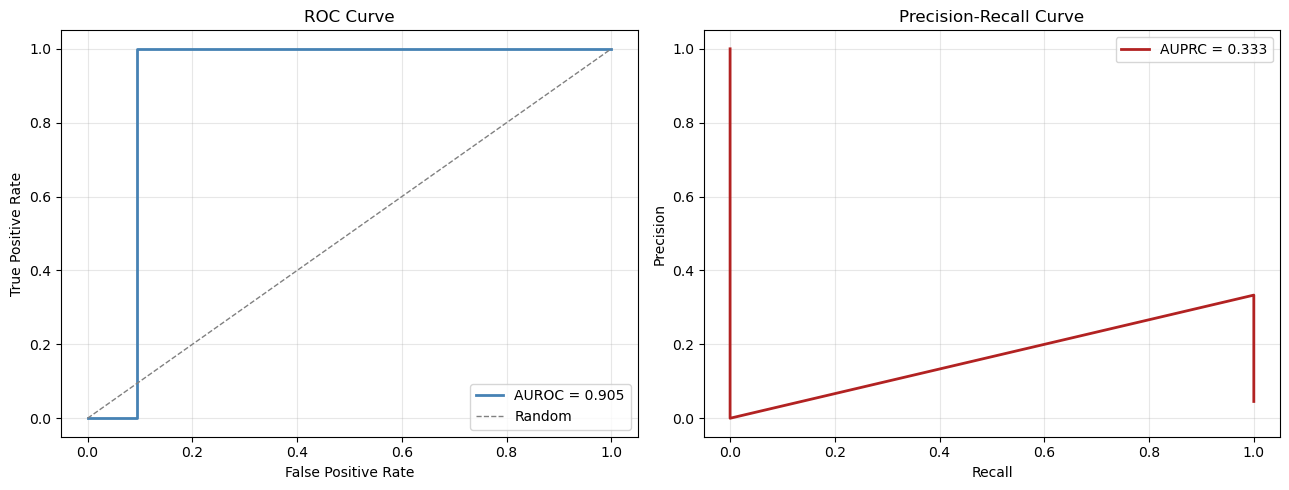

Saved roc_pr_curves.png


In [6]:
if auroc == auroc:  # not NaN
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    prec, rec, _ = precision_recall_curve(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUROC = {auroc:.3f}')
    axes[0].plot([0,1],[0,1],'--', color='gray', lw=1, label='Random')
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(rec, prec, color='firebrick', lw=2, label=f'AUPRC = {auprc:.3f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'roc_pr_curves.png'), dpi=120)
    plt.show()
    print('Saved roc_pr_curves.png')
else:
    print('Skipping curves — single class in labels')

## 4. Stage 6 — Alert Generator

In [7]:
from src.stage6_output.alert_generator import AlertGenerator
from src.stage5_analysis.anomaly_detector import AnomalyDetector

alert_gen = AlertGenerator(mortality_warning_threshold=0.20, mortality_critical_threshold=0.40)
detector  = AnomalyDetector()

lab_anom = [
    {'name':'Creatinine','value':3.2,'direction':'HIGH','severity':0.85},
    {'name':'Lactate',   'value':4.1,'direction':'HIGH','severity':0.72},
]
vital_anom = [
    {'vital_name':'heart_rate','current_value':148,'status':'HIGH','trend':'RISING'},
    {'vital_name':'spo2',      'current_value':86, 'status':'LOW', 'trend':'FALLING'},
]

alerts = alert_gen.generate_all_alerts(lab_anom, vital_anom, mortality_prob=0.45, deterioration_detected=True)
print(f'Total alerts: {len(alerts)}')
for a in alerts:
    print(f'  [{a.priority:8s}] [{a.category:9s}] {a.title}')

Total alerts: 6
  [CRITICAL] [LAB      ] Creatinine HIGH
  [CRITICAL] [LAB      ] Lactate HIGH
  [CRITICAL] [VITAL    ] spo2 LOW
  [CRITICAL] [MORTALITY] High Mortality Risk
  [CRITICAL] [TREND    ] Rapid Clinical Deterioration Detected
  [WARNING ] [VITAL    ] heart_rate HIGH


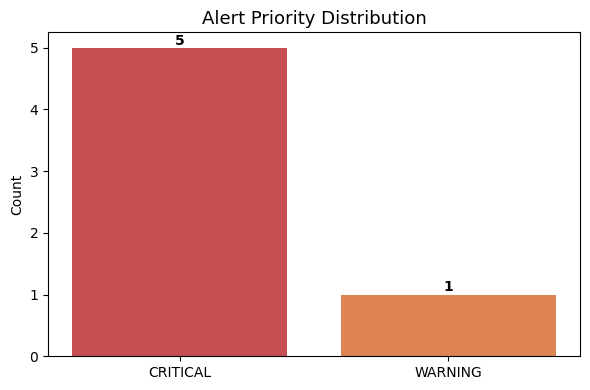

In [8]:
from collections import Counter
priority_counts = Counter(a.priority for a in alerts)
colors = {'CRITICAL':'#C44E52','WARNING':'#DD8452','INFO':'#55A868'}
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(priority_counts.keys(), priority_counts.values(),
              color=[colors.get(k,'gray') for k in priority_counts])
ax.set_title('Alert Priority Distribution', fontsize=13)
ax.set_ylabel('Count')
for bar, val in zip(bars, priority_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.05, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'alert_distribution.png'), dpi=120)
plt.show()

## 5. Stage 6 — Patient Summary Builder

In [9]:
from src.stage6_output.patient_summary import PatientSummaryBuilder

builder = PatientSummaryBuilder()
summary = builder.build(
    subject_id=12345, hadm_id=678901,
    demographics={'age': 67, 'gender': 'M'},
    admission_info={'admittime': '2024-01-01', 'dischtime': '2024-01-06', 'los_days': 5.2},
    note_text='Patient admitted with sepsis and acute kidney injury.',
    lab_anomalies=lab_anom,
    vital_anomalies=vital_anom,
    vital_trends={},
    mortality_result={'probability': 0.45, 'risk_level': 'HIGH'},
)
print(json.dumps(summary, indent=2, default=str))

{
  "patient_id": "12345_678901",
  "subject_id": 12345,
  "hadm_id": 678901,
  "demographics": {
    "age": 67,
    "gender": "M"
  },
  "admission": {
    "admittime": "2024-01-01",
    "dischtime": "2024-01-06",
    "los_days": 5.2
  },
  "diagnoses": [],
  "medications": [],
  "predicted_mortality": {
    "probability": 0.45,
    "risk_level": "HIGH"
  },
  "lab_summary": {
    "n_abnormal": 2,
    "top_abnormal": [
      {
        "name": "Creatinine",
        "value": 3.2,
        "direction": "HIGH",
        "severity": 0.85
      },
      {
        "name": "Lactate",
        "value": 4.1,
        "direction": "HIGH",
        "severity": 0.72
      }
    ]
  },
  "vital_summary": {
    "alerts": [
      {
        "vital_name": "heart_rate",
        "current_value": 148,
        "status": "HIGH",
        "trend": "RISING"
      },
      {
        "vital_name": "spo2",
        "current_value": 86,
        "status": "LOW",
        "trend": "FALLING"
      }
    ],
    "trend_overvi

## 6. Stage 6 — Dashboard Exporter

In [10]:
from src.stage6_output.dashboard_data import DashboardDataExporter
from pathlib import Path

exporter = DashboardDataExporter(output_dir=Path(SUMMARY_DIR))
exporter.export_patient_summary(summary)
print('Single patient JSON saved')

all_summaries = []
for hid in hadm_ids:
    hid = int(hid)
    row = cohort_df[cohort_df['hadm_id'] == hid]
    if row.empty: continue
    row  = row.iloc[0]
    prob = mortality_probs.get(hid, 0.0)
    risk = 'HIGH' if prob >= 0.30 else ('MEDIUM' if prob >= 0.10 else 'LOW')
    all_summaries.append({
        'patient_id': f"{int(row['subject_id'])}_{hid}",
        'subject_id': int(row['subject_id']),
        'hadm_id': hid,
        'demographics': {'age': row.get('anchor_age'), 'gender': row.get('gender')},
        'predicted_mortality': {'probability': round(prob, 4), 'risk_level': risk},
        'lab_summary': {'n_abnormal': 0, 'top_abnormal': []},
        'vital_summary': {'alerts': [], 'trend_overview': {}},
        'clinical_summary': f'Predicted mortality {prob*100:.1f}% ({risk}).',
        'diagnoses': [], 'medications': [], 'admission': {},
    })

overview_path = exporter.export_cohort_overview(all_summaries)
print(f'Cohort overview saved: {overview_path}')
print(f'Total patients: {len(all_summaries)}')

Single patient JSON saved
Cohort overview saved: ..\outputs\summaries\cohort_overview.json
Total patients: 22


## 7. Stage 6 — Report Exporter

In [11]:
from src.stage6_output.report_exporter import ReportExporter

reporter  = ReportExporter(output_dir=Path(SUMMARY_DIR))
all_paths = reporter.export_batch_json(all_summaries)
print(f'Exported {len(all_paths)} patient reports to {SUMMARY_DIR}')

Exported 22 patient reports to ..\outputs\summaries


## 8. Risk Distribution

Risk distribution: {'HIGH': 22}


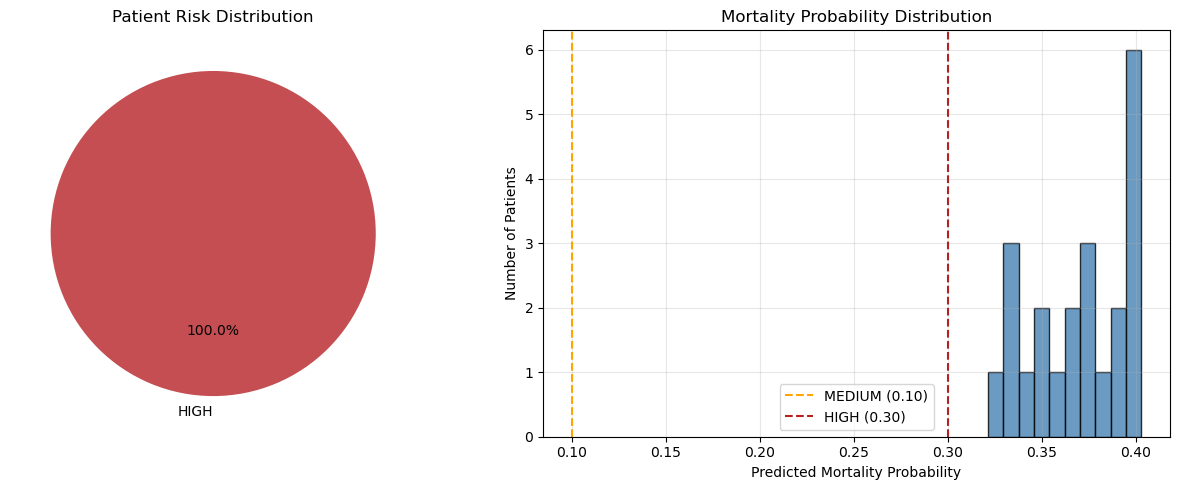

Saved risk_distribution.png


In [12]:
risk_counts = Counter(
    'HIGH' if p >= 0.30 else ('MEDIUM' if p >= 0.10 else 'LOW')
    for p in mortality_probs.values()
)
print('Risk distribution:', dict(risk_counts))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
risk_colors = {'LOW':'#55A868','MEDIUM':'#DD8452','HIGH':'#C44E52'}
axes[0].pie(risk_counts.values(), labels=risk_counts.keys(),
            colors=[risk_colors[k] for k in risk_counts],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Patient Risk Distribution')
axes[1].hist(list(mortality_probs.values()), bins=10, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(0.10, color='orange',   linestyle='--', lw=1.5, label='MEDIUM (0.10)')
axes[1].axvline(0.30, color='firebrick', linestyle='--', lw=1.5, label='HIGH (0.30)')
axes[1].set_xlabel('Predicted Mortality Probability')
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Mortality Probability Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'risk_distribution.png'), dpi=120)
plt.show()
print('Saved risk_distribution.png')

## 9. Final Summary

In [13]:
print('=' * 55)
print('  ClinNote — Pipeline Evaluation Complete')
print('=' * 55)
print(f'  Patients evaluated  : {len(all_summaries)}')
print(f'  AUROC               : {auroc:.4f}' if auroc == auroc else '  AUROC: N/A (single class)')
print(f'  AUPRC               : {auprc:.4f}' if auprc == auprc else '  AUPRC: N/A')
print(f'  HIGH risk           : {risk_counts.get("HIGH", 0)}')
print(f'  MEDIUM risk         : {risk_counts.get("MEDIUM", 0)}')
print(f'  LOW risk            : {risk_counts.get("LOW", 0)}')
print(f'  Total alerts (demo) : {len(alerts)}')
print(f'  Reports saved to    : {SUMMARY_DIR}')
print('=' * 55)

  ClinNote — Pipeline Evaluation Complete
  Patients evaluated  : 22
  AUROC               : 0.9048
  AUPRC               : 0.3333
  HIGH risk           : 22
  MEDIUM risk         : 0
  LOW risk            : 0
  Total alerts (demo) : 6
  Reports saved to    : ..\outputs\summaries
